# 03 - Feature engineering

Turning the cleaned table into a model-ready matrix:

1. derive a few columns the EDA suggested (`avg_monthly_charge`, `charge_ratio`,
   `num_services`, `tenure_group`);
2. split off the 20% test set **before** anything is fitted, so no test-set statistics leak
   into the scaler or the encoder;
3. fit the encoder + scaler on the training rows, look at the encoded matrix and rank the
   features with mutual information.

The helpers are in `src/features.py` so the app can call the same code.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import CLEAN_PATH, TARGET, load_clean, split_features_target
from src.features import ENGINEERED_NUMERIC, add_features, build_preprocessor, feature_names, numeric_features

FIG = PROJECT_ROOT / "reports" / "figures"
MODELS = PROJECT_ROOT / "models"
PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = load_clean(CLEAN_PATH)
X_raw, y = split_features_target(df)
X_raw.shape

(7043, 19)

## Derived features

* `avg_monthly_charge` - `TotalCharges / tenure`, what the customer has actually been paying on
  average. It decorrelates the two charge columns (see the EDA correlation matrix). First-month
  customers have no history, so it is simply their current price.
* `charge_ratio` - `MonthlyCharges / avg_monthly_charge`. A ratio above 1 means the current bill
  is higher than the customer's historical average, i.e. their price has crept up.
* `num_services` - how many of the six add-on services are switched on.
* `tenure_group` - the same buckets used in the EDA.

None of these learn anything from the data - they are row-wise arithmetic - so it is safe to
compute them on the full table before splitting.

In [2]:
X_fe = add_features(X_raw)
X_fe[["tenure", "MonthlyCharges", "TotalCharges"] + ENGINEERED_NUMERIC + ["tenure_group"]].head(8)

,tenure,MonthlyCharges,TotalCharges,avg_monthly_charge,num_services,charge_ratio,tenure_group
0,1,29.85,29.85,29.850000,1,1.000000,0-12
1,34,56.95,1889.50,55.573529,2,1.024768,25-48
2,2,53.85,108.15,54.075000,2,0.995839,0-12
3,45,42.30,1840.75,40.905556,3,1.034089,25-48
4,2,70.70,151.65,75.825000,0,0.932410,0-12
5,8,99.65,820.50,102.562500,3,0.971603,0-12
6,22,89.10,1949.40,88.609091,2,1.005540,13-24
7,10,29.75,301.90,30.190000,1,0.985426,0-12


In [3]:
X_fe[ENGINEERED_NUMERIC].describe().round(3)

,avg_monthly_charge,num_services,charge_ratio
count,7043.000,7043.000,7043.000
mean,64.763,2.038,1.002
std,30.190,1.848,0.051
min,13.775,0.000,0.636
25%,35.935,0.000,0.981
50%,70.338,2.000,1.000
75%,90.174,3.000,1.021
max,121.400,6.000,1.451


num_services
0    21.4
1    45.8
2    35.8
3    27.4
4    22.3
5    12.4
6     5.3
Name: Churn, dtype: float64

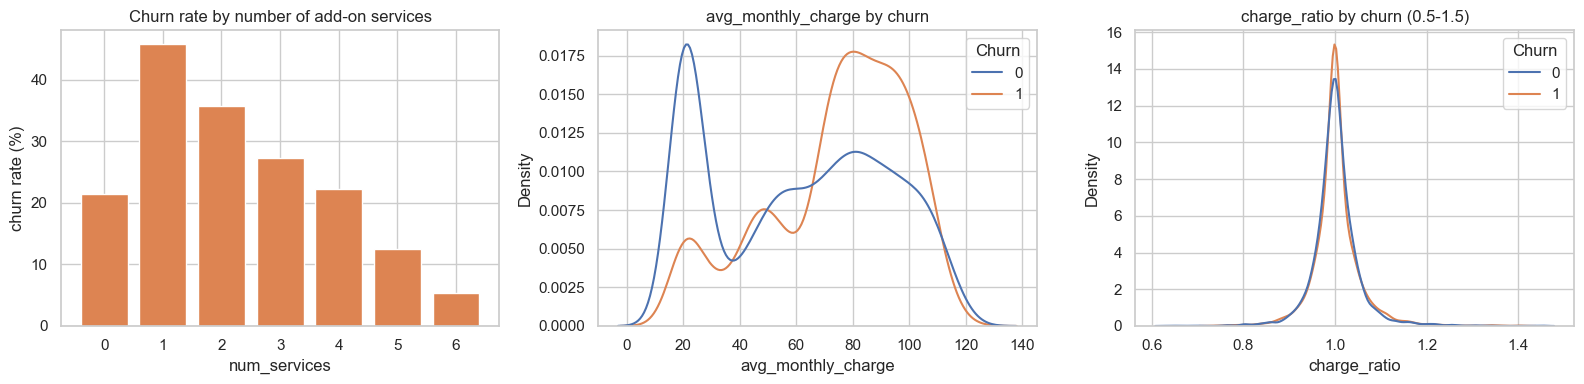

In [4]:
tmp = X_fe.assign(Churn=y.values)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
rate = tmp.groupby("num_services")["Churn"].mean() * 100
axes[0].bar(rate.index, rate.values, color="#dd8452")
axes[0].set_title("Churn rate by number of add-on services")
axes[0].set_xlabel("num_services"); axes[0].set_ylabel("churn rate (%)")
sns.kdeplot(data=tmp, x="avg_monthly_charge", hue="Churn", common_norm=False, ax=axes[1])
axes[1].set_title("avg_monthly_charge by churn")
sns.kdeplot(data=tmp[tmp["charge_ratio"].between(0.5, 1.5)], x="charge_ratio", hue="Churn", common_norm=False, ax=axes[2])
axes[2].set_title("charge_ratio by churn (0.5-1.5)")
fig.tight_layout()
fig.savefig(FIG / "10_engineered_features.png")
rate.round(1)

Churn is highest for customers with exactly one or two add-ons (46% and 36%) and falls steadily
as more services are bundled - customers with five or six add-ons churn at 12% and 5%. Customers
with zero add-ons sit in the middle because that group mixes "no internet at all" (very low
churn) with "fiber and nothing else" (high churn).

`charge_ratio` is a small but real effect: the churned density sits to the right of 1.0, meaning
churners are more often paying above their historical average.

## Train / test split

A stratified 80/20 split, done once here and reused by every later notebook. The test rows are
written to disk and not touched again until the final scoring pass in notebook 04.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fe, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("train:", X_train.shape, "churn rate", round(y_train.mean(), 4))
print("test :", X_test.shape, "churn rate", round(y_test.mean(), 4))

train: (5634, 23) churn rate 0.2654
test : (1409, 23) churn rate 0.2654


In [6]:
X_train.assign(**{TARGET: y_train.values}).to_csv(PROCESSED / "train.csv", index=False)
X_test.assign(**{TARGET: y_test.values}).to_csv(PROCESSED / "test.csv", index=False)

## Encoding and scaling

`build_preprocessor()` returns a `ColumnTransformer` that standardises the numeric columns and
one-hot encodes every categorical (dropping the first level of each to avoid redundant dummies).
It is fitted on the training rows only. Notebook 04 refits a fresh copy inside each
cross-validation fold; the one saved here is for inspecting the matrix and for the tests.

In [7]:
preprocessor = build_preprocessor()
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)
joblib.dump(preprocessor, MODELS / "preprocessor.joblib")
print(X_train_enc.shape, X_test_enc.shape)
X_train_enc.head()

(5634, 29) (1409, 29)


,tenure,MonthlyCharges,TotalCharges,avg_monthly_charge,num_services,charge_ratio,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13-24,tenure_group_25-48,tenure_group_49-72
3738,0.102371,-0.521976,-0.262257,-0.539986,0.507935,0.195142,1,0,0,0,...,1,0,0,0,0,1,0,0,1,0
3151,-0.711743,0.337478,-0.503635,0.391496,-0.570530,-0.465108,1,0,1,1,...,0,0,0,0,0,0,1,1,0,0
4860,-0.793155,-0.809013,-0.749883,-0.646102,0.507935,-2.135732,1,0,1,1,...,0,0,1,0,0,0,1,1,0,0
3867,-0.263980,0.284384,-0.172722,0.276552,1.047168,0.015395,0,0,1,0,...,1,0,1,1,1,0,0,0,1,0
3810,-1.281624,-0.676279,-0.989374,-0.674608,-1.109762,-0.039073,1,0,1,1,...,0,0,0,0,0,1,0,0,0,0


In [8]:
feature_columns = feature_names(preprocessor)
with open(MODELS / "feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=2)
feature_columns

['tenure',
 'MonthlyCharges',
 'TotalCharges',
 'avg_monthly_charge',
 'num_services',
 'charge_ratio',
 'gender_Male',
 'SeniorCitizen_Yes',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_Yes',
 'OnlineBackup_Yes',
 'DeviceProtection_Yes',
 'TechSupport_Yes',
 'StreamingTV_Yes',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'tenure_group_13-24',
 'tenure_group_25-48',
 'tenure_group_49-72']

A quick sanity check that the scaler really only saw the training rows: the standardised
training columns have mean 0 / std 1, while the test columns do not sit exactly on 0 / 1.

In [9]:
pd.DataFrame(
    {
        "train_mean": X_train_enc[numeric_features()].mean(),
        "train_std": X_train_enc[numeric_features()].std(ddof=0),
        "test_mean": X_test_enc[numeric_features()].mean(),
        "test_std": X_test_enc[numeric_features()].std(ddof=0),
    }
).round(3)

,train_mean,train_std,test_mean,test_std
tenure,-0.0,1.0,-0.023,0.998
MonthlyCharges,-0.0,1.0,-0.028,0.992
TotalCharges,0.0,1.0,-0.043,0.972
avg_monthly_charge,-0.0,1.0,-0.029,0.994
num_services,0.0,1.0,-0.054,0.980
charge_ratio,0.0,1.0,0.031,1.018


## Which features carry signal?

Mutual information between each encoded column and the target, computed on the training split.
It is a quick, model-agnostic ranking that handles the non-linear relationships (tenure,
charges) better than correlation.

tenure                            0.0655
Contract_Two year                 0.0605
InternetService_Fiber optic       0.0493
MonthlyCharges                    0.0492
PaymentMethod_Electronic check    0.0461
TotalCharges                      0.0392
tenure_group_49-72                0.0371
avg_monthly_charge                0.0332
InternetService_No                0.0318
charge_ratio                      0.0268
num_services                      0.0256
PaperlessBilling_Yes              0.0205
Contract_One year                 0.0184
OnlineSecurity_Yes                0.0165
Dependents_Yes                    0.0151
dtype: float64

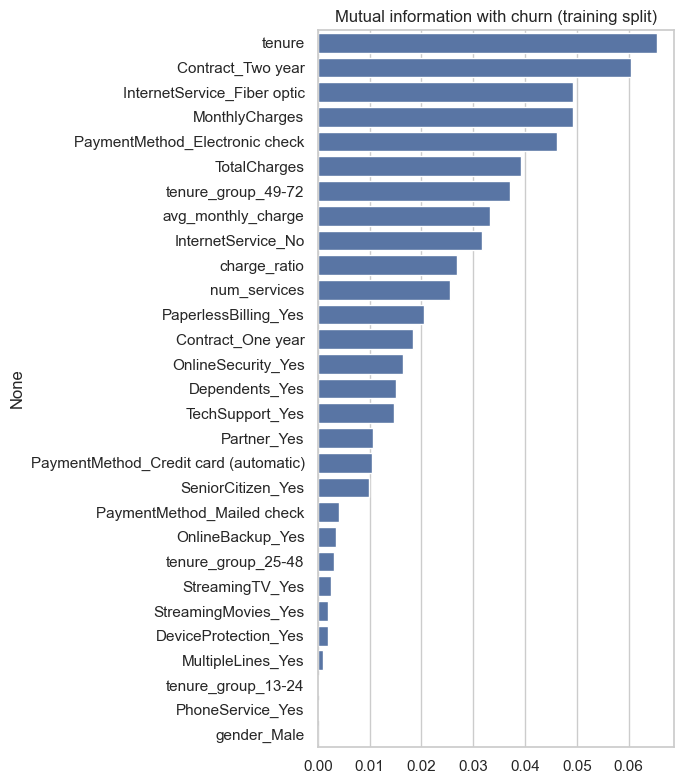

In [10]:
discrete = [c not in numeric_features() for c in X_train_enc.columns]
mi = mutual_info_classif(X_train_enc, y_train, discrete_features=discrete, random_state=RANDOM_STATE)
mi = pd.Series(mi, index=X_train_enc.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 8))
sns.barplot(x=mi.values, y=mi.index, ax=ax, color="#4c72b0")
ax.set_title("Mutual information with churn (training split)")
fig.tight_layout()
fig.savefig(FIG / "11_mutual_information.png")
mi.round(4).head(15)

The ranking agrees with the EDA: tenure-related columns, contract, the two charge columns and
internet service dominate, while `gender`, `PhoneService` and the streaming add-ons contribute
almost nothing. I keep the full set for now - tree models are robust to a few weak columns and
the total is only 29 features - and let the explainability step (notebook 05) confirm which ones
the final model actually uses.